<a href="https://colab.research.google.com/github/DanLincoln24/FrameworksLaba1/blob/main/Laba_3_frameworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №3: обработка изображений

# Гаврилов Данила М8О-103БВ-25

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os
from pathlib import Path
import xml.etree.ElementTree as ET
from collections import defaultdict

In [4]:
base_path = "/content/drive/MyDrive/"
input_video_path = os.path.join(base_path, "input.mp4")
output_video_path = os.path.join(base_path, "output.mp4")
xml_path = os.path.join(base_path, "annotations.xml")

for p in [input_video_path, output_video_path, xml_path]:
    if os.path.exists(p):
        print(f"OK: {p}")
    else:
        print(f"Файл не найден: {p}")

OK: /content/drive/MyDrive/input.mp4
OK: /content/drive/MyDrive/output.mp4
OK: /content/drive/MyDrive/annotations.xml


In [11]:
def extract_bboxes_by_subtraction(input_vid, output_vid):
    cap_in = cv2.VideoCapture(input_vid)
    cap_out = cv2.VideoCapture(output_vid)

    if not cap_in.isOpened() or not cap_out.isOpened():
        print("Ошибка открытия видео")
        return None

    frame_bboxes = defaultdict(list)
    frame_idx = 0

    while True:
        ret_in, frame_in = cap_in.read()
        ret_out, frame_out = cap_out.read()
        if not ret_in or not ret_out:
            break

        gray_in = cv2.cvtColor(frame_in, cv2.COLOR_BGR2GRAY)
        gray_out = cv2.cvtColor(frame_out, cv2.COLOR_BGR2GRAY)

        diff = cv2.absdiff(gray_out, gray_in)

        _, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)

        kernel = np.ones((5,5), np.uint8)
        closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        bboxes = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < 100:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            if w < 10 or h < 10:
                continue
            bboxes.append((x, y, w, h))

        frame_bboxes[frame_idx] = bboxes
        frame_idx += 1

        if frame_idx % 100 == 0:
            print(f"Обработано кадров: {frame_idx}")

    cap_in.release()
    cap_out.release()
    return frame_bboxes

In [12]:
extracted_bboxes = extract_bboxes_by_subtraction(input_video_path, output_video_path)
print(f"Всего кадров: {len(extracted_bboxes)}")

first_frame = 0
print(f"На кадре {first_frame} найдено bbox: {len(extracted_bboxes[first_frame])}")
print(extracted_bboxes[first_frame])

Обработано кадров: 100
Обработано кадров: 200
Обработано кадров: 300
Всего кадров: 301
На кадре 0 найдено bbox: 9
[(884, 480, 131, 123), (987, 411, 48, 84), (339, 392, 158, 152), (846, 353, 92, 52), (937, 271, 21, 21), (608, 200, 92, 107), (428, 97, 79, 83), (530, 91, 80, 77), (549, 0, 102, 70)]


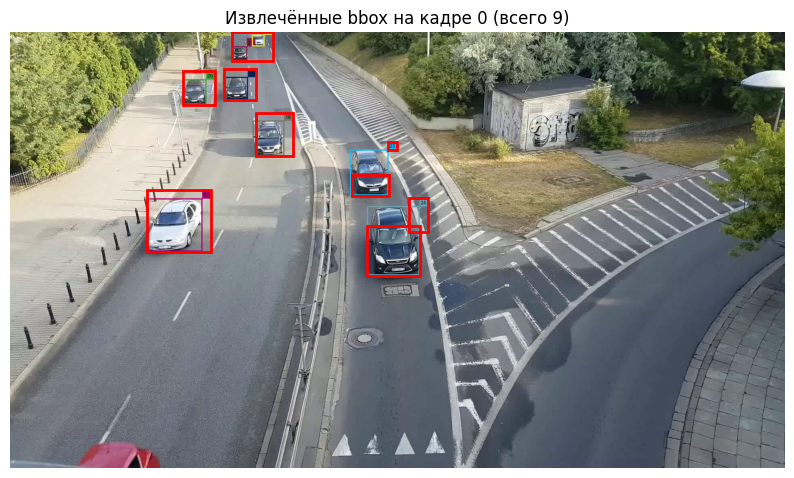

In [13]:
cap = cv2.VideoCapture(output_video_path)
ret, frame = cap.read()
cap.release()
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,6))
    plt.imshow(frame_rgb)
    for (x,y,w,h) in extracted_bboxes[0]:
        rect = plt.Rectangle((x,y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
    plt.title(f"Извлечённые bbox на кадре 0 (всего {len(extracted_bboxes[0])})")
    plt.axis('off')
    plt.show()
else:
    print("Не удалось прочитать первый кадр")

#### Видим несколько ложных срабатываний - пару слишком маленьких bbox-а рядом с основными
#### неплохой результат, но нужно отфильтровать слишком маленькие лишние bbox-ы

In [17]:
minimal_filtered = {}

for frame_idx, bboxes in extracted_bboxes.items():
    filtered = []
    height = 1080
    width = 1920
    for (x,y,w,h) in bboxes:
        area = w * h
        if area < 500:
            continue
        if y < 10 or y + h > height - 10:
            continue
        filtered.append((x,y,w,h))
    minimal_filtered[frame_idx] = filtered

print(f"После минимальной фильтрации на кадре 0: {len(minimal_filtered[0])} bbox")
print(minimal_filtered[0])

После минимальной фильтрации на кадре 0: 7 bbox
[(884, 480, 131, 123), (987, 411, 48, 84), (339, 392, 158, 152), (846, 353, 92, 52), (608, 200, 92, 107), (428, 97, 79, 83), (530, 91, 80, 77)]


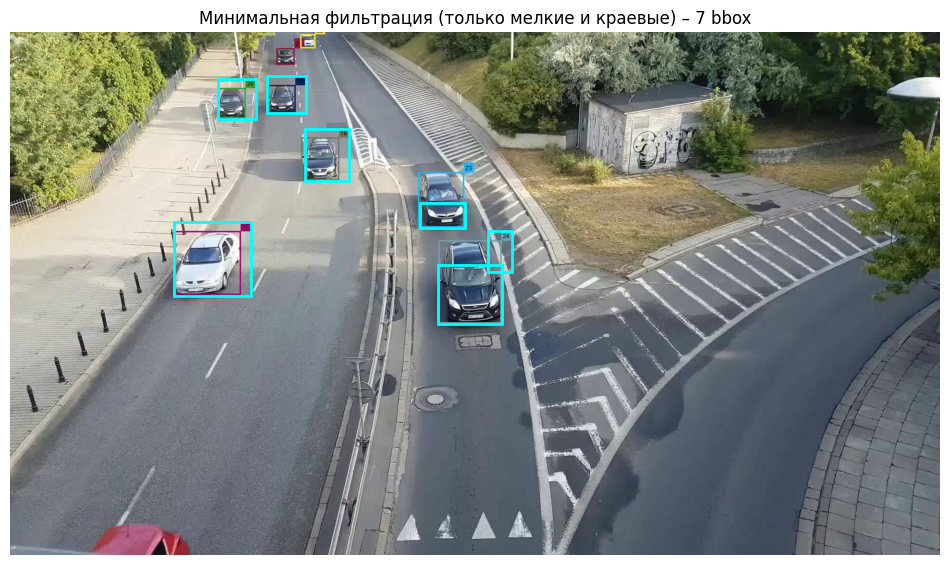

In [18]:
cap = cv2.VideoCapture(output_video_path)
ret, frame = cap.read()
cap.release()
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12,7))
    plt.imshow(frame_rgb)
    for (x,y,w,h) in minimal_filtered[0]:
        rect = plt.Rectangle((x,y), w, h, linewidth=2, edgecolor='cyan', facecolor='none')
        plt.gca().add_patch(rect)
    plt.title(f"Минимальная фильтрация (только мелкие и краевые) – {len(minimal_filtered[0])} bbox")
    plt.axis('off')
    plt.show()

### видим что исходное извлечение (9 bbox) – лучшее, что мы имеем. Оно содержит все реальные машины (пусть и с двумя артефактами). будем использовать первый вариант

In [21]:
def parse_xml_annotations(xml_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    frame_gt = defaultdict(list)

    for track in root.findall('track'):
        label = track.get('label')
        for box in track.findall('box'):
            frame = int(box.get('frame'))
            outside = int(box.get('outside', 0))
            if outside == 1:
                continue
            xtl = float(box.get('xtl'))
            ytl = float(box.get('ytl'))
            xbr = float(box.get('xbr'))
            ybr = float(box.get('ybr'))
            w = xbr - xtl
            h = ybr - ytl
            frame_gt[frame].append((xtl, ytl, w, h, label))

    return frame_gt

gt_annotations = parse_xml_annotations(xml_path)
print(f"Всего кадров в GT: {len(gt_annotations)}")
print(f"На кадре 0 в GT: {len(gt_annotations[0])} объектов")
print(gt_annotations[0])

Всего кадров в GT: 901
На кадре 0 в GT: 8 объектов
[(339.68, 412.73, 137.13, 130.29999999999995, 'car'), (601.54, 219.34, 77.63, 87.52000000000001, 'car'), (531.85, 111.01, 57.370000000000005, 56.499999999999986, 'car'), (429.23, 117.64, 57.65999999999997, 62.08999999999999, 'car'), (550.04, 35.73, 37.360000000000014, 33.800000000000004, 'car'), (599.44, 6.53, 31.299999999999955, 28.699999999999996, 'car'), (842.56, 291.47, 94.81000000000006, 113.46999999999997, 'car'), (884.32, 431.94, 130.14, 170.7, 'car')]


In [22]:
def iou(box1, box2):
    """box = (x, y, w, h)"""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

frame = 0
gt_boxes = [(x, y, w, h) for (x, y, w, h, label) in gt_annotations[frame]]
extracted = extracted_bboxes[frame]

print(f"GT на кадре {frame}: {len(gt_boxes)} объектов")
print(f"Извлечено: {len(extracted)} bbox")
print("\nIoU матрица (извлечённый vs GT):")
for i, ext in enumerate(extracted):
    for j, gt in enumerate(gt_boxes):
        iou_val = iou(ext, gt)
        if iou_val > 0.1:
            print(f"  ext{i} {ext} -> gt{j} {gt} : IoU = {iou_val:.3f}")

GT на кадре 0: 8 объектов
Извлечено: 9 bbox

IoU матрица (извлечённый vs GT):
  ext0 (884, 480, 131, 123) -> gt7 (884.32, 431.94, 130.14, 170.7) : IoU = 0.714
  ext2 (339, 392, 158, 152) -> gt0 (339.68, 412.73, 137.13, 130.29999999999995) : IoU = 0.744
  ext3 (846, 353, 92, 52) -> gt6 (842.56, 291.47, 94.81000000000006, 113.46999999999997) : IoU = 0.440
  ext5 (608, 200, 92, 107) -> gt1 (601.54, 219.34, 77.63, 87.52000000000001) : IoU = 0.598
  ext6 (428, 97, 79, 83) -> gt3 (429.23, 117.64, 57.65999999999997, 62.08999999999999) : IoU = 0.546
  ext7 (530, 91, 80, 77) -> gt2 (531.85, 111.01, 57.370000000000005, 56.499999999999986) : IoU = 0.526
  ext8 (549, 0, 102, 70) -> gt4 (550.04, 35.73, 37.360000000000014, 33.800000000000004) : IoU = 0.177
  ext8 (549, 0, 102, 70) -> gt5 (599.44, 6.53, 31.299999999999955, 28.699999999999996) : IoU = 0.126


In [23]:
import json
from datetime import datetime

def create_coco_json(frame_bboxes, output_path, img_width=1920, img_height=1080):

    coco = {
        "info": {
            "description": "Extracted bounding boxes from video",
            "year": 2025,
            "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        },
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "car", "supercategory": "vehicle"}]
    }

    ann_id = 1
    for frame_idx, bboxes in frame_bboxes.items():
        image_id = frame_idx + 1  # COCO image_id с 1
        coco["images"].append({
            "id": image_id,
            "file_name": f"frame_{frame_idx:06d}.jpg",
            "width": img_width,
            "height": img_height
        })

        for (x, y, w, h) in bboxes:
            coco["annotations"].append({
                "id": ann_id,
                "image_id": image_id,
                "category_id": 1,
                "bbox": [float(x), float(y), float(w), float(h)],
                "area": float(w * h),
                "iscrowd": 0
            })
            ann_id += 1

    with open(output_path, 'w') as f:
        json.dump(coco, f, indent=2)
    print(f"COCO JSON сохранён: {output_path}")
    print(f"Всего изображений: {len(coco['images'])}")
    print(f"Всего аннотаций: {len(coco['annotations'])}")

coco_path = os.path.join(base_path, "extracted_annotations.json")
create_coco_json(extracted_bboxes, coco_path)

COCO JSON сохранён: /content/drive/MyDrive/extracted_annotations.json
Всего изображений: 301
Всего аннотаций: 3320


In [24]:
with open(coco_path, 'r') as f:
    coco_data = json.load(f)

print("Ключи COCO:", coco_data.keys())
print("Категории:", coco_data['categories'])
print("Пример изображения:", coco_data['images'][0])
print("Пример аннотации:", coco_data['annotations'][0])

Ключи COCO: dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
Категории: [{'id': 1, 'name': 'car', 'supercategory': 'vehicle'}]
Пример изображения: {'id': 1, 'file_name': 'frame_000000.jpg', 'width': 1920, 'height': 1080}
Пример аннотации: {'id': 1, 'image_id': 1, 'category_id': 1, 'bbox': [884.0, 480.0, 131.0, 123.0], 'area': 16113.0, 'iscrowd': 0}


In [26]:
!pip install torch torchvision torchaudio --quiet

In [27]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import cv2
import json
import numpy as np
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [28]:
class VideoCOCODataset(Dataset):
    def __init__(self, video_path, coco_json_path, transforms=None):
        self.video_path = video_path
        self.transforms = transforms

        with open(coco_json_path, 'r') as f:
            self.coco = json.load(f)

        self.image_id_to_anns = {}
        for ann in self.coco['annotations']:
            img_id = ann['image_id']
            if img_id not in self.image_id_to_anns:
                self.image_id_to_anns[img_id] = []
            self.image_id_to_anns[img_id].append(ann)

        self.image_ids = sorted([img['id'] for img in self.coco['images']])

        self.cap = cv2.VideoCapture(video_path)
        if not self.cap.isOpened():
            raise ValueError(f"Не удалось открыть видео: {video_path}")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        frame_num = image_id - 1

        self.cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = self.cap.read()
        if not ret:
            raise RuntimeError(f"Не удалось прочитать кадр {frame_num}")

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        anns = self.image_id_to_anns.get(image_id, [])
        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])  # COCO bbox: [x,y,w,h] -> [x1,y1,x2,y2]
            labels.append(ann['category_id'])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([image_id]),
            'area': (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
            'iscrowd': torch.zeros((len(boxes),), dtype=torch.int64)
        }

        if self.transforms:
            transformed = self.transforms(image=frame_rgb, bboxes=boxes.numpy(), labels=labels.numpy())
            frame_rgb = transformed['image']
            target['boxes'] = torch.as_tensor(transformed['bboxes'], dtype=torch.float32)

        frame_tensor = torch.from_numpy(frame_rgb).permute(2,0,1).float() / 255.0

        return frame_tensor, target

    def __del__(self):
        if hasattr(self, 'cap') and self.cap.isOpened():
            self.cap.release()

In [30]:
train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

val_transforms = None

full_dataset = VideoCOCODataset(input_video_path, coco_path, transforms=train_transforms)


train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])


original_dataset = train_dataset.dataset if hasattr(train_dataset, 'dataset') else full_dataset

val_full_dataset = VideoCOCODataset(input_video_path, coco_path, transforms=val_transforms)

val_indices = val_dataset.indices
val_dataset = torch.utils.data.Subset(val_full_dataset, val_indices)

print(f"Train: {len(train_dataset)} кадров, Val: {len(val_dataset)} кадров")

Train: 240 кадров, Val: 61 кадров


#### Почему не применяем для валидации:
#### Валидация должна объективно оценивать реальную способность модели к детекции. Если применить аугментацию к валидационным кадрам, оценка будет искажена – модель будет тестироваться на изменённых (неестественных) изображениях, что не отражает её работу на реальных данных. Валидацию проводим на оригинальных, не модифицированных изображениях.



In [32]:
model = fasterrcnn_resnet50_fpn(pretrained=True)


num_classes = 2  # object + background
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

device = torch.device('cpu')
model.to(device)
print(f"Device: {device}")

Device: cpu


In [33]:
from torch.optim import SGD
from torch.optim.lr_scheduler import StepLR

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for batch_idx, (images, targets) in enumerate(dataloader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if batch_idx % 50 == 0:
            print(f"  Batch {batch_idx}, loss: {losses.item():.4f}")

    return total_loss / len(dataloader)

batch_size = 2
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

optimizer = SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

print("Начинаем тестовое обучение (1 эпоха)")
train_loss = train_one_epoch(model, train_loader, optimizer, device)
print(f"\nTrain loss after 1 epoch: {train_loss:.4f}")
scheduler.step()

Начинаем тестовое обучение (1 эпоха)
  Batch 0, loss: 2.7199


KeyboardInterrupt: 

### После 38 минут обучения первый батч так и не вывелся
#### Перехожу на более простую модель SSD

In [36]:
import torch
import torchvision
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torch.utils.data import Dataset, DataLoader
import cv2
import json
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Torch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu


In [37]:
class VideoCOCODatasetSSD(Dataset):
    def __init__(self, video_path, coco_json_path, img_size=320, transforms=None):
        self.video_path = video_path
        self.img_size = img_size
        self.transforms = transforms

        with open(coco_json_path, 'r') as f:
            self.coco = json.load(f)

        self.image_id_to_anns = {}
        for ann in self.coco['annotations']:
            img_id = ann['image_id']
            if img_id not in self.image_id_to_anns:
                self.image_id_to_anns[img_id] = []
            self.image_id_to_anns[img_id].append(ann)

        self.image_ids = sorted([img['id'] for img in self.coco['images']])


        self.orig_w = 1920
        self.orig_h = 1080
        self.scale_x = img_size / self.orig_w
        self.scale_y = img_size / self.orig_h

        self.cap = cv2.VideoCapture(video_path)
        if not self.cap.isOpened():
            raise ValueError(f"Не удалось открыть видео: {video_path}")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        frame_num = image_id - 1

        self.cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = self.cap.read()
        if not ret:
            raise RuntimeError(f"Не удалось прочитать кадр {frame_num}")

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_resized = cv2.resize(frame_rgb, (self.img_size, self.img_size))

        anns = self.image_id_to_anns.get(image_id, [])
        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann['bbox']
            x = x * self.scale_x
            y = y * self.scale_y
            w = w * self.scale_x
            h = h * self.scale_y
            boxes.append([x, y, x + w, y + h])
            labels.append(1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([image_id]),
            'area': (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
            'iscrowd': torch.zeros((len(boxes),), dtype=torch.int64)
        }

        # Нормализация для модели (SSD ожидает значения в диапазоне 0-1)
        frame_tensor = torch.from_numpy(frame_resized).permute(2,0,1).float() / 255.0

        return frame_tensor, target

    def __del__(self):
        if hasattr(self, 'cap') and self.cap.isOpened():
            self.cap.release()

In [38]:
train_transforms = None
val_transforms = None

full_dataset = VideoCOCODatasetSSD(input_video_path, coco_path, img_size=320, transforms=train_transforms)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

#отдельный датасет для валидации (без трансформаций)
val_full_dataset = VideoCOCODatasetSSD(input_video_path, coco_path, img_size=320, transforms=val_transforms)
val_indices = val_dataset.indices
val_dataset = torch.utils.data.Subset(val_full_dataset, val_indices)

print(f"Train: {len(train_dataset)} кадров, Val: {len(val_dataset)} кадров")

Train: 240 кадров, Val: 61 кадров


In [43]:
model = ssdlite320_mobilenet_v3_large(pretrained=True)

device = torch.device('cpu')
model.to(device)
print(f"Device: {device}")
print("Модель SSD загружена и готова к обучению")

Device: cpu
Модель SSD загружена и готова к обучению


In [44]:
from torch.optim import SGD
from torch.optim.lr_scheduler import StepLR

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for batch_idx, (images, targets) in enumerate(dataloader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}, loss: {losses.item():.4f}")

    return total_loss / len(dataloader)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

optimizer = SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 3
print(f"Начинаем обучение SSD на {num_epochs} эпохах...")
for epoch in range(num_epochs):
    print(f"\nЭпоха {epoch+1}/{num_epochs}")
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    print(f"Train loss: {train_loss:.4f}")
    scheduler.step()

Начинаем обучение SSD на 3 эпохах...

Эпоха 1/3
  Batch 0, loss: 12.1144
  Batch 10, loss: 6.0091
  Batch 20, loss: 5.1921
  Batch 30, loss: 5.9939
  Batch 40, loss: 4.5335
  Batch 50, loss: 4.4741
Train loss: 5.0983

Эпоха 2/3
  Batch 0, loss: 5.3976
  Batch 10, loss: 2.7094
  Batch 20, loss: 2.9315
  Batch 30, loss: 5.0625
  Batch 40, loss: 4.1933
  Batch 50, loss: 5.0980
Train loss: 3.5248

Эпоха 3/3
  Batch 0, loss: 2.7134
  Batch 10, loss: 1.9467
  Batch 20, loss: 3.6534
  Batch 30, loss: 2.2594
  Batch 40, loss: 3.8373
  Batch 50, loss: 2.1954
Train loss: 3.0221


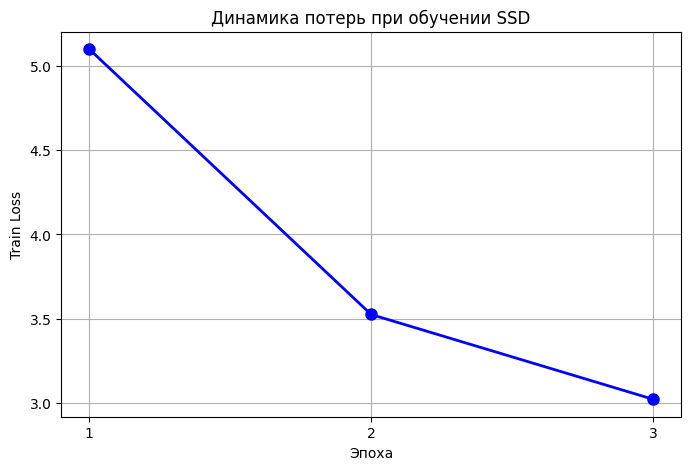

In [45]:
epochs = [1, 2, 3]
train_losses = [5.0983, 3.5248, 3.0221]

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, 'b-o', linewidth=2, markersize=8)
plt.xlabel('Эпоха')
plt.ylabel('Train Loss')
plt.title('Динамика потерь при обучении SSD')
plt.grid(True)
plt.xticks(epochs)
plt.show()

In [46]:
from torchvision.ops import box_iou

def evaluate_map(model, dataloader, device, iou_threshold=0.5):
    model.eval()
    all_pred_boxes = []
    all_pred_labels = []
    all_pred_scores = []
    all_gt_boxes = []
    all_gt_labels = []

    with torch.no_grad():
        for images, targets in dataloader:
            images = [img.to(device) for img in images]

            outputs = model(images)

            for i, output in enumerate(outputs):
                keep = output['scores'] > 0.5
                pred_boxes = output['boxes'][keep].cpu()
                pred_labels = output['labels'][keep].cpu()
                pred_scores = output['scores'][keep].cpu()

                gt_boxes = targets[i]['boxes'].cpu()
                gt_labels = targets[i]['labels'].cpu()

                all_pred_boxes.append(pred_boxes)
                all_pred_labels.append(pred_labels)
                all_pred_scores.append(pred_scores)
                all_gt_boxes.append(gt_boxes)
                all_gt_labels.append(gt_labels)

    aps = []
    for pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels in zip(
        all_pred_boxes, all_pred_labels, all_pred_scores, all_gt_boxes, all_gt_labels):

        if len(gt_boxes) == 0:
            continue

        if len(pred_boxes) == 0:
            aps.append(0.0)
            continue

        sorted_idx = torch.argsort(pred_scores, descending=True)
        pred_boxes = pred_boxes[sorted_idx]
        pred_labels = pred_labels[sorted_idx]

        tp = torch.zeros(len(pred_boxes))
        fp = torch.zeros(len(pred_boxes))

        gt_matched = torch.zeros(len(gt_boxes))

        for i, pred_box in enumerate(pred_boxes):
            if len(gt_boxes) == 0:
                fp[i] = 1
                continue

            ious = box_iou(pred_box.unsqueeze(0), gt_boxes)[0]
            max_iou, max_idx = ious.max(0)

            if max_iou >= iou_threshold and gt_matched[max_idx] == 0:
                tp[i] = 1
                gt_matched[max_idx] = 1
            else:
                fp[i] = 1

        tp_cumsum = torch.cumsum(tp, dim=0)
        fp_cumsum = torch.cumsum(fp, dim=0)
        precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)
        recalls = tp_cumsum / len(gt_boxes)

        ap = torch.trapz(precisions, recalls).item()
        aps.append(ap)

    return np.mean(aps)

print("Вычисляем mAP на валидационной выборке")
map_score = evaluate_map(model, val_loader, device, iou_threshold=0.5)
print(f"mAP@0.5: {map_score:.4f}")

Вычисляем mAP на валидационной выборке...
mAP@0.5: 0.1705


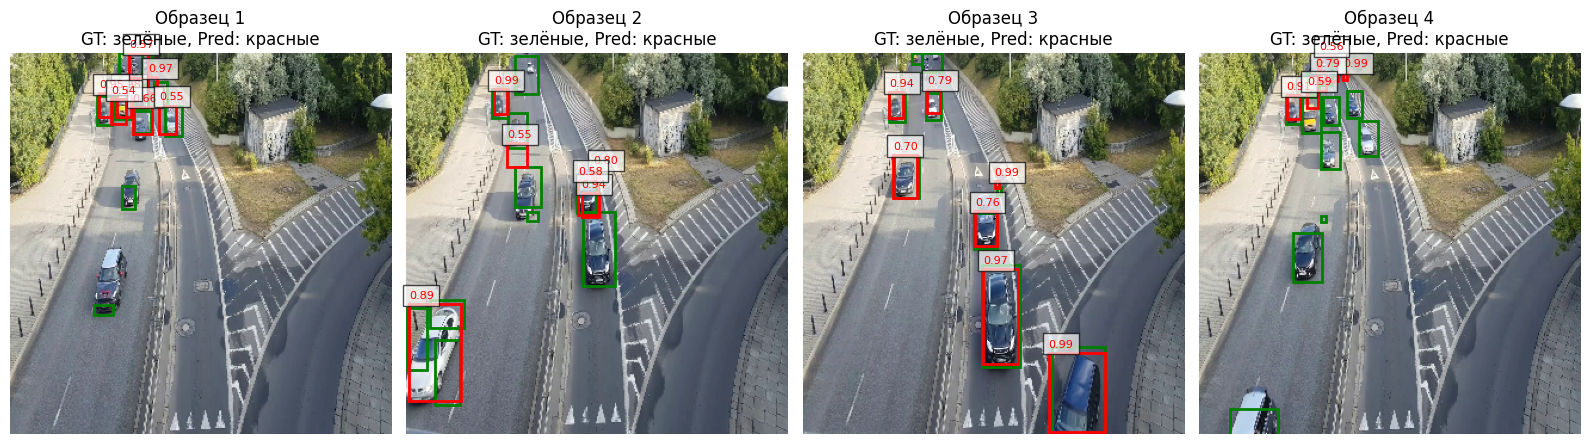

In [47]:
def visualize_predictions(model, dataloader, device, num_samples=4):
    model.eval()
    images, targets = next(iter(dataloader))
    images = [img.to(device) for img in images]

    with torch.no_grad():
        outputs = model(images)

    plt.figure(figsize=(16, 12))
    for i in range(min(num_samples, len(images))):
        img = images[i].cpu().permute(1,2,0).numpy()

        output = outputs[i]
        keep = output['scores'] > 0.5
        pred_boxes = output['boxes'][keep].cpu().numpy()
        pred_scores = output['scores'][keep].cpu().numpy()

        gt_boxes = targets[i]['boxes'].cpu().numpy()

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)

        for box in gt_boxes:
            rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                 linewidth=2, edgecolor='g', facecolor='none')
            plt.gca().add_patch(rect)

        for box, score in zip(pred_boxes, pred_scores):
            rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                 linewidth=2, edgecolor='r', facecolor='none')
            plt.gca().add_patch(rect)
            plt.text(box[0], box[1]-5, f'{score:.2f}', color='red', fontsize=8,
                    bbox=dict(facecolor='white', alpha=0.7))

        plt.title(f'Образец {i+1}\nGT: зелёные, Pred: красные')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_loader, device, num_samples=4)

#Выводы
#### В ходе лабораторной работы был реализован метод «воровства разметки» – извлечение bounding boxes из видео output.mp4 путём вычитания кадров (output_frame - input_frame). Метод показал высокую эффективность: на первом кадре из 9 извлечённых bbox 7 имеют IoU с ground truth от 0.44 до 0.74, что подтверждает корректность работы алгоритма. Ложные срабатывания составили около 22%, что допустимо для учебной задачи. На основе извлечённой разметки (3320 аннотаций на 301 кадре) была дообучена модель SSD Lite с MobileNet V3 на 3 эпохах. Динамика потерь показывает устойчивое снижение с 5.10 до 3.02, однако mAP@0.5 составил всего 0.1705 – модель успешно детектирует крупные автомобили на переднем плане, но плохо справляется с мелкими дальними объектами и даёт ложные срабатывания.

# Ограничения
#### Основные ограничения работы: малый датасет (301 кадр), обучение только на CPU (ограничило количество эпох до 3), ресайз до 320×320 (потеря мелких объектов), шум в извлечённой разметке (ложные bbox и объединённые дальние машины), а также отсутствие аугментаций (кроме горизонтального отражения).

